# Chicago Crime Analytics — Exploratory Analysis

This notebook uses Pandas, NumPy, and Matplotlib to explore temporal,
category, indicator, and community-area patterns in 761,563 official
reported-incident records covering the complete calendar years
2023–2025.

All results are descriptive. Counts are not population-normalized crime
rates, arrest percentages are not clearance or conviction rates, source
timestamps may be estimated, and observed patterns do not establish
causation.

## 1. Environment and secure read-only database connection

In [1]:
from pathlib import Path
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv
from IPython.display import display
from sqlalchemy import URL, create_engine, text

%matplotlib inline


def find_project_root() -> Path:
    """Find the repository root whether execution starts there or in notebooks/."""
    candidates = [Path.cwd(), *Path.cwd().parents]
    for candidate in candidates:
        if (candidate / ".env.example").exists() and (candidate / "sql").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate the project root containing .env.example and sql/.")


PROJECT_ROOT = find_project_root()
load_dotenv(PROJECT_ROOT / ".env", override=False)

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

print("Project root located from the current working directory.")
print(f"Pandas: {pd.__version__} | NumPy: {np.__version__} | Matplotlib: {plt.matplotlib.__version__}")

Project root located from the current working directory.
Pandas: 2.3.3 | NumPy: 2.0.2 | Matplotlib: 3.9.4


In [2]:
def build_read_only_engine():
    """Create a read-only PostgreSQL engine without printing credentials."""
    host = os.getenv("POSTGRES_HOST") or None
    user = os.getenv("POSTGRES_USER") or None
    password = os.getenv("POSTGRES_PASSWORD") or None
    database = os.getenv("POSTGRES_DB", "chicago_crime")
    port = int(os.getenv("POSTGRES_PORT", "5432")) if host else None

    url = URL.create(
        "postgresql+psycopg",
        username=user,
        password=password,
        host=host,
        port=port,
        database=database,
    )
    connect_args = {"options": "-c default_transaction_read_only=on"}
    sslmode = os.getenv("POSTGRES_SSLMODE")
    if host and sslmode:
        connect_args["sslmode"] = sslmode

    engine = create_engine(url, future=True, connect_args=connect_args)
    return engine, database, host


engine, database_name, database_host = build_read_only_engine()
with engine.connect() as connection:
    connection_check = pd.read_sql_query(
        text("""
            SELECT current_database() AS database_name,
                   current_setting('transaction_read_only') AS transaction_read_only
        """),
        connection,
    )

assert connection_check.loc[0, "transaction_read_only"] == "on"
print(
    f"Connected securely to {database_name} via "
    f"{'host ' + database_host if database_host else 'local PostgreSQL socket'}; "
    "transactions are read-only."
)
display(connection_check)

Connected securely to chicago_crime via local PostgreSQL socket; transactions are read-only.


,database_name,transaction_read_only
0,chicago_crime,on


## 2. Load analytical fields from PostgreSQL

The notebook reads the canonical clean table and performs its own Pandas
aggregations rather than using SQL view totals as plotted inputs.

In [3]:
BASE_QUERY = text("""
    SELECT source_id,
           crime_date,
           crime_year,
           crime_month,
           month_name,
           season,
           day_of_week_num,
           day_of_week,
           hour_of_day,
           primary_type,
           arrest,
           domestic,
           community_area,
           community_area_eligible_flag
    FROM public.clean_chicago_crimes
    ORDER BY source_id
""")

records = pd.read_sql_query(BASE_QUERY, engine, parse_dates=["crime_date"])

integer_columns = [
    "source_id", "crime_year", "crime_month", "day_of_week_num", "hour_of_day"
]
for column in integer_columns:
    records[column] = pd.to_numeric(records[column], errors="raise")

print(f"Loaded {len(records):,} clean records with {records['source_id'].nunique():,} unique source IDs.")
print(f"Date coverage: {records['crime_date'].min().date()} through {records['crime_date'].max().date()}")
display(records.head(3))

Loaded 761,563 clean records with 761,563 unique source IDs.
Date coverage: 2023-01-01 through 2025-12-31


,source_id,crime_date,crime_year,crime_month,month_name,season,day_of_week_num,day_of_week,hour_of_day,primary_type,arrest,domestic,community_area,community_area_eligible_flag
0,27279,2023-01-01,2023,1,January,Winter,7,Sunday,5,HOMICIDE,True,False,24.0000,True
1,27280,2023-01-01,2023,1,January,Winter,7,Sunday,4,HOMICIDE,True,False,60.0000,True
2,27281,2023-01-01,2023,1,January,Winter,7,Sunday,9,HOMICIDE,True,False,49.0000,True


In [4]:
FIGURE_DIR = PROJECT_ROOT / "images" / "python"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

BLUE = "#1f77b4"
ORANGE = "#ff7f0e"
GREEN = "#2ca02c"
RED = "#d62728"
PURPLE = "#9467bd"
GRAY = "#6b7280"

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titleweight": "bold",
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


def save_figure(fig, filename):
    path = FIGURE_DIR / filename
    fig.text(
        0.01,
        0.01,
        "Source: City of Chicago Crimes - 2001 to Present (ijzp-q8t2); complete years 2023-2025.",
        ha="left",
        fontsize=7.5,
        color=GRAY,
    )
    fig.tight_layout(rect=[0, 0.045, 1, 1])
    fig.savefig(path, dpi=160, bbox_inches="tight", facecolor="white")
    plt.show()
    plt.close(fig)
    print(f"Saved {path.relative_to(PROJECT_ROOT)}")

## 3. Complete-year trend and year-over-year change

,crime_year,reported_incident_count,previous_year_count,absolute_change,percentage_change
0,2023,263844,NaN,NaN,NaN
1,2024,259633,"263,844.0000","-4,211.0000",-1.5960
2,2025,238086,"259,633.0000","-21,547.0000",-8.2990


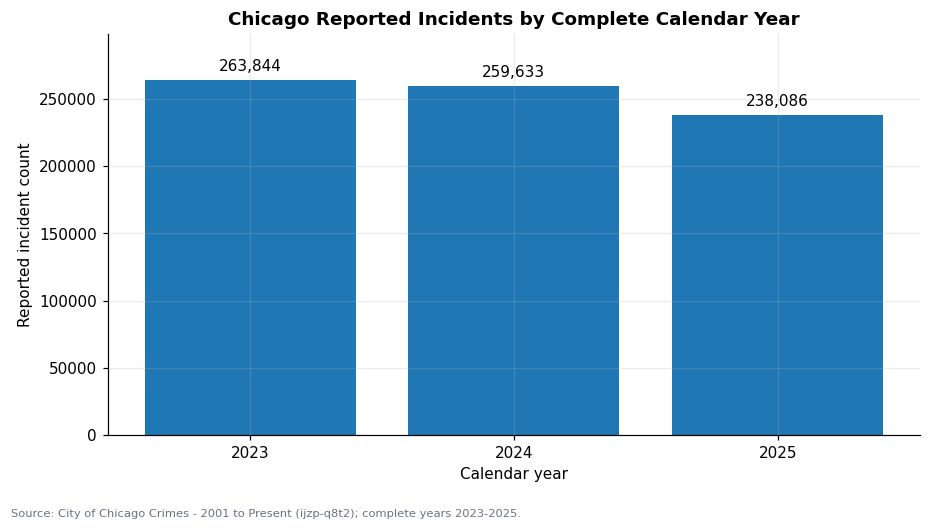

Saved images/python/python_yearly_trend.png


In [5]:
yearly = (
    records.groupby("crime_year", as_index=False)
    .size()
    .rename(columns={"size": "reported_incident_count"})
    .sort_values("crime_year")
)
yearly["previous_year_count"] = yearly["reported_incident_count"].shift(1)
yearly["absolute_change"] = yearly["reported_incident_count"] - yearly["previous_year_count"]
yearly["percentage_change"] = np.where(
    yearly["previous_year_count"].eq(0),
    np.nan,
    100.0 * yearly["absolute_change"] / yearly["previous_year_count"],
)
display(yearly.round(4))

fig, ax = plt.subplots(figsize=(8.5, 4.8))
bars = ax.bar(yearly["crime_year"].astype(str), yearly["reported_incident_count"], color=BLUE)
ax.bar_label(bars, labels=[f"{value:,}" for value in yearly["reported_incident_count"]], padding=4)
ax.set_title("Chicago Reported Incidents by Complete Calendar Year")
ax.set_xlabel("Calendar year")
ax.set_ylabel("Reported incident count")
ax.set_ylim(0, yearly["reported_incident_count"].max() * 1.13)
ax.ticklabel_format(axis="y", style="plain")
save_figure(fig, "python_yearly_trend.png")

**Interpretation:** Both adjacent-year comparisons declined, with the
larger change occurring in 2025. This is a change in reported records,
not evidence about why reporting or incident volume changed.

## 4. Monthly trend, rolling average, and seasonal pattern

Months in 2025 below the corresponding 2024 month: 12 of 12


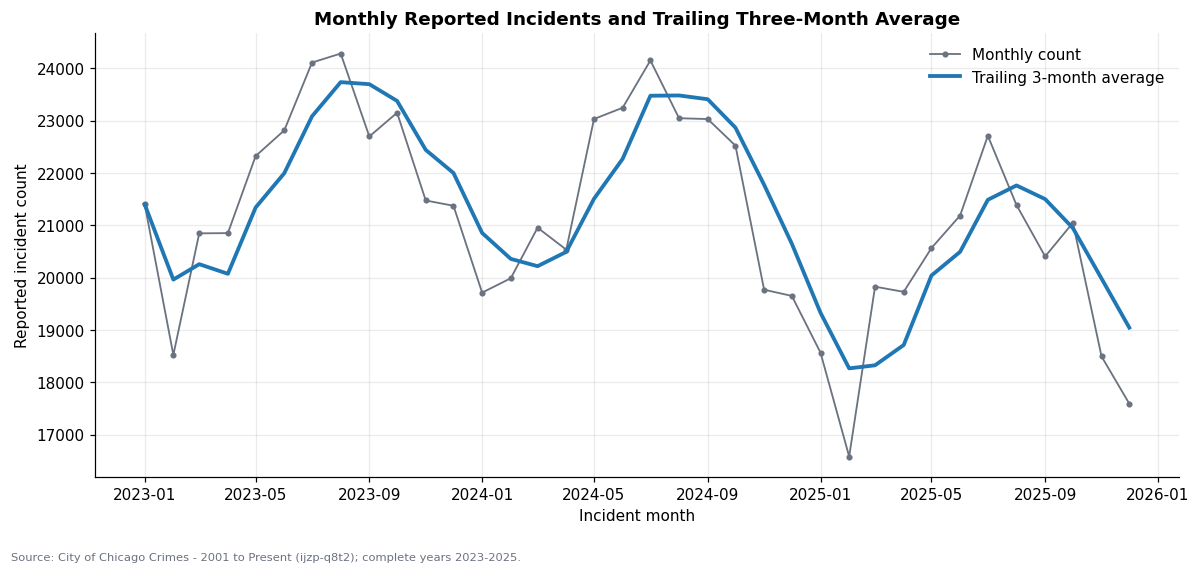

Saved images/python/python_monthly_rolling_trend.png


In [6]:
monthly = (
    records.assign(month_start=records["crime_date"].dt.to_period("M").dt.to_timestamp())
    .groupby("month_start", as_index=False)
    .size()
    .rename(columns={"size": "reported_incident_count"})
    .sort_values("month_start")
)
monthly["three_month_rolling_average"] = (
    monthly["reported_incident_count"].rolling(window=3, min_periods=1).mean()
)
monthly["crime_year"] = monthly["month_start"].dt.year
monthly["crime_month"] = monthly["month_start"].dt.month
monthly["same_month_previous_year_count"] = (
    monthly.groupby("crime_month")["reported_incident_count"].shift(1)
)
monthly["same_month_change"] = (
    monthly["reported_incident_count"] - monthly["same_month_previous_year_count"]
)

months_lower_2025 = int(
    monthly.loc[monthly["crime_year"].eq(2025), "same_month_change"].lt(0).sum()
)
print(f"Months in 2025 below the corresponding 2024 month: {months_lower_2025} of 12")

fig, ax = plt.subplots(figsize=(11, 5.2))
ax.plot(monthly["month_start"], monthly["reported_incident_count"], color=GRAY,
        marker="o", markersize=3, linewidth=1.2, label="Monthly count")
ax.plot(monthly["month_start"], monthly["three_month_rolling_average"], color=BLUE,
        linewidth=2.5, label="Trailing 3-month average")
ax.set_title("Monthly Reported Incidents and Trailing Three-Month Average")
ax.set_xlabel("Incident month")
ax.set_ylabel("Reported incident count")
ax.legend(frameon=False)
save_figure(fig, "python_monthly_rolling_trend.png")

,crime_year,season,reported_incident_count,year_total,percentage_of_year
3,2023,Winter,61297,263844,23.2323
1,2023,Spring,64019,263844,24.2640
2,2023,Summer,71206,263844,26.9879
0,2023,Fall,67322,263844,25.5158
7,2024,Winter,59351,259633,22.8596
5,2024,Spring,64519,259633,24.8501
6,2024,Summer,70442,259633,27.1314
4,2024,Fall,65321,259633,25.1590
11,2025,Winter,52738,238086,22.1508
9,2025,Spring,60120,238086,25.2514


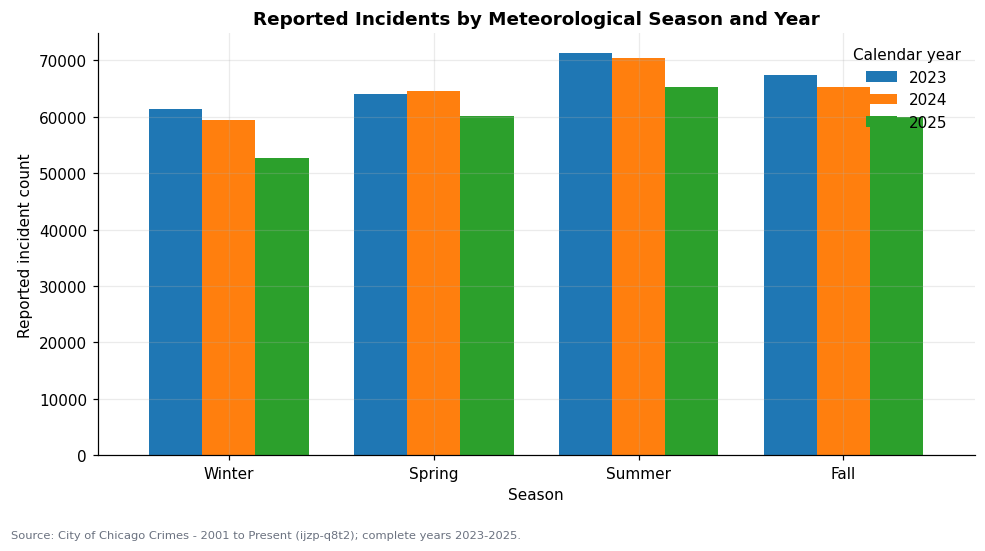

Saved images/python/python_seasonal_by_year.png


In [7]:
season_order = ["Winter", "Spring", "Summer", "Fall"]
seasonal = (
    records.groupby(["crime_year", "season"], observed=True)
    .size()
    .rename("reported_incident_count")
    .reset_index()
)
seasonal["season"] = pd.Categorical(seasonal["season"], categories=season_order, ordered=True)
seasonal = seasonal.sort_values(["crime_year", "season"])
seasonal["year_total"] = seasonal.groupby("crime_year")["reported_incident_count"].transform("sum")
seasonal["percentage_of_year"] = 100.0 * seasonal["reported_incident_count"] / seasonal["year_total"]
display(seasonal.round(4))

seasonal_pivot = seasonal.pivot(index="season", columns="crime_year", values="reported_incident_count").reindex(season_order)
fig, ax = plt.subplots(figsize=(9, 5))
seasonal_pivot.plot(kind="bar", ax=ax, color=[BLUE, ORANGE, GREEN], width=0.78)
ax.set_title("Reported Incidents by Meteorological Season and Year")
ax.set_xlabel("Season")
ax.set_ylabel("Reported incident count")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Calendar year", frameon=False)
save_figure(fig, "python_seasonal_by_year.png")

**Interpretation:** The rolling series makes the broad annual decline
visible without hiding monthly variation. Seasonal counts remain
unadjusted for season length, weather, mobility, or other exposure.

## 5. Day-of-week and hourly patterns

,day_of_week_num,day_of_week,observed_dates,average_per_observed_date,reported_incident_count
0,1,Monday,157,695.4400,109184
1,2,Tuesday,157,683.7100,107342
2,3,Wednesday,157,687.7600,107978
3,4,Thursday,156,681.0700,106247
4,5,Friday,156,714.2600,111425
5,6,Saturday,156,707.7200,110404
6,7,Sunday,157,694.1600,108983


,hour_of_day,reported_incident_count,percentage_of_total
0,0,54217,7.1192
12,12,43582,5.7227
15,15,41437,5.4410
17,17,40955,5.3778
16,16,40606,5.3319


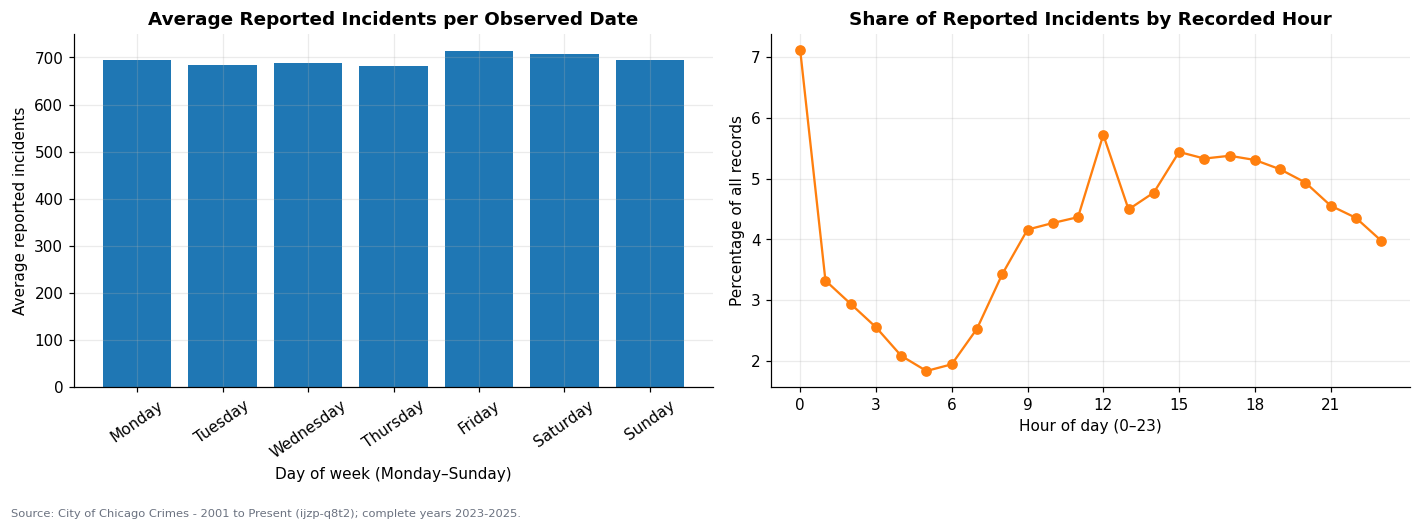

Saved images/python/python_weekday_hourly_patterns.png


In [8]:
daily = (
    records.groupby(["crime_date", "day_of_week_num", "day_of_week"], as_index=False)
    .size()
    .rename(columns={"size": "daily_incident_count"})
)
weekday = (
    daily.groupby(["day_of_week_num", "day_of_week"], as_index=False)
    .agg(
        observed_dates=("crime_date", "nunique"),
        average_per_observed_date=("daily_incident_count", "mean"),
        reported_incident_count=("daily_incident_count", "sum"),
    )
    .sort_values("day_of_week_num")
)
hourly = (
    records.groupby("hour_of_day", as_index=False)
    .size()
    .rename(columns={"size": "reported_incident_count"})
)
hourly["percentage_of_total"] = 100.0 * hourly["reported_incident_count"] / len(records)
display(weekday.round(2))
display(hourly.sort_values("reported_incident_count", ascending=False).head(5).round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].bar(weekday["day_of_week"], weekday["average_per_observed_date"], color=BLUE)
axes[0].set_title("Average Reported Incidents per Observed Date")
axes[0].set_xlabel("Day of week (Monday–Sunday)")
axes[0].set_ylabel("Average reported incidents")
axes[0].tick_params(axis="x", rotation=35)

axes[1].plot(hourly["hour_of_day"], hourly["percentage_of_total"], color=ORANGE, marker="o")
axes[1].set_title("Share of Reported Incidents by Recorded Hour")
axes[1].set_xlabel("Hour of day (0–23)")
axes[1].set_ylabel("Percentage of all records")
axes[1].set_xticks(range(0, 24, 3))
save_figure(fig, "python_weekday_hourly_patterns.png")

**Interpretation:** Per-date weekday averages avoid comparing five
weekdays directly with two weekend days. Exact-hour results require
caution because source incident times may be estimated; the midnight
concentration may partly reflect recording practices.

## 6. Crime-category trends

primary_type,THEFT,BATTERY,CRIMINAL DAMAGE,MOTOR VEHICLE THEFT,ASSAULT,OTHER OFFENSE,DECEPTIVE PRACTICE,ROBBERY
crime_year,,,,,,,,
2023,57526,44303,30098,29256,22642,15747,17657,11059
2024,60558,46187,28557,21712,23487,17169,16459,9120
2025,55198,42660,26248,17257,21601,16851,15329,5817


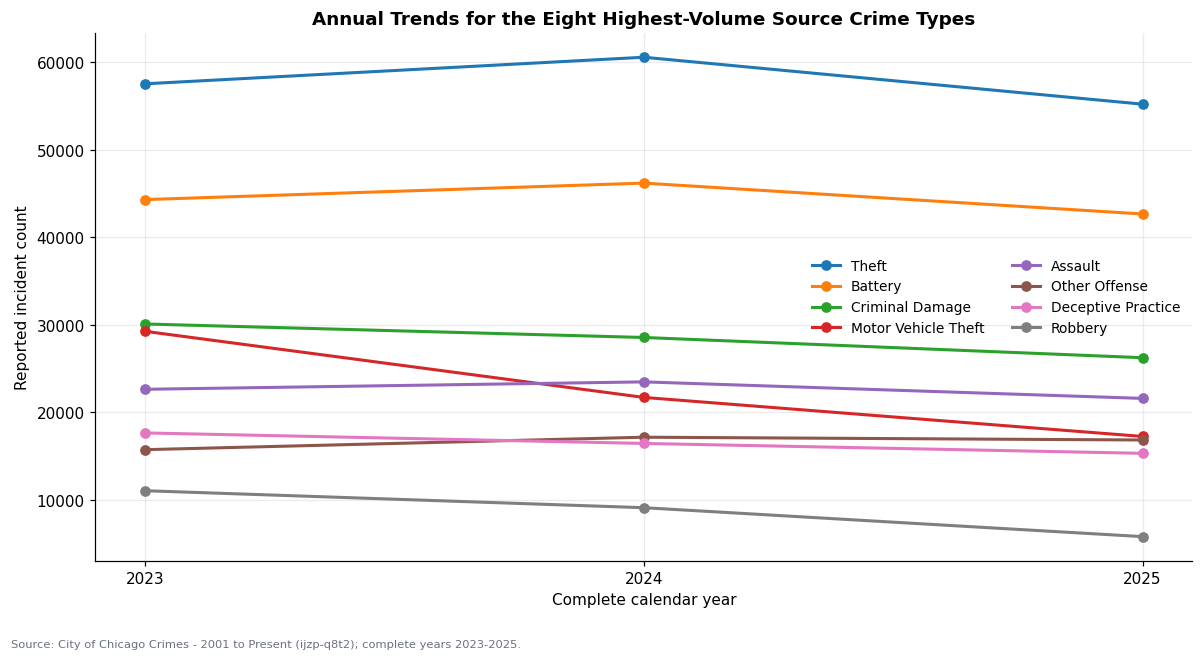

Saved images/python/python_category_yearly_trends.png


In [9]:
category_totals = records["primary_type"].value_counts()
top_categories = category_totals.head(8).index.tolist()
category_year = (
    records.loc[records["primary_type"].isin(top_categories)]
    .groupby(["crime_year", "primary_type"], as_index=False)
    .size()
    .rename(columns={"size": "reported_incident_count"})
)
category_pivot = (
    category_year.pivot(index="crime_year", columns="primary_type", values="reported_incident_count")
    .reindex(columns=top_categories)
)
display(category_pivot)

fig, ax = plt.subplots(figsize=(11, 6))
for category in top_categories:
    ax.plot(category_pivot.index, category_pivot[category], marker="o", linewidth=2, label=category.title())
ax.set_title("Annual Trends for the Eight Highest-Volume Source Crime Types")
ax.set_xlabel("Complete calendar year")
ax.set_ylabel("Reported incident count")
ax.set_xticks(category_pivot.index)
ax.legend(frameon=False, ncol=2, fontsize=9)
save_figure(fig, "python_category_yearly_trends.png")

### Category-specific calendar-month profiles

To move beyond repeating citywide SQL totals, the next analysis compares
each leading category's distribution across calendar months. Each row
sums to 100%, so the heatmap emphasizes within-category timing rather
than category size.

,primary_type,peak_month,peak_share_pct,lowest_month,lowest_share_pct
0,THEFT,Jul,9.6213,Feb,6.9932
1,BATTERY,Jul,9.2993,Feb,7.0004
2,CRIMINAL DAMAGE,Jul,9.6015,Feb,6.6688
3,MOTOR VEHICLE THEFT,Jul,9.2034,Dec,7.5471
4,ASSAULT,May,9.2810,Feb,6.8876
5,OTHER OFFENSE,Mar,8.7809,Nov,7.7602


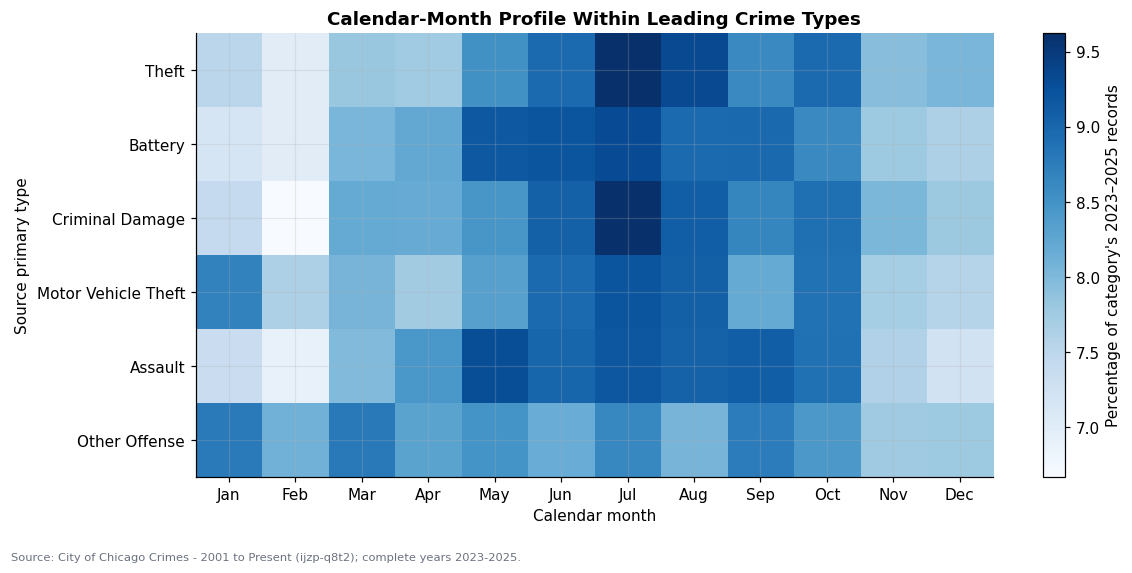

Saved images/python/python_category_monthly_profile.png


In [10]:
profile_categories = category_totals.head(6).index.tolist()
category_month = (
    records.loc[records["primary_type"].isin(profile_categories)]
    .groupby(["primary_type", "crime_month"], as_index=False)
    .size()
    .rename(columns={"size": "reported_incident_count"})
)
category_month["category_total"] = (
    category_month.groupby("primary_type")["reported_incident_count"].transform("sum")
)
category_month["percentage_of_category_total"] = (
    100.0 * category_month["reported_incident_count"] / category_month["category_total"]
)
profile = (
    category_month.pivot(
        index="primary_type", columns="crime_month", values="percentage_of_category_total"
    )
    .reindex(profile_categories)
)
month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
peak_months = pd.DataFrame({
    "primary_type": profile.index,
    "peak_month": [month_labels[int(month) - 1] for month in profile.idxmax(axis=1)],
    "peak_share_pct": profile.max(axis=1).to_numpy(),
    "lowest_month": [month_labels[int(month) - 1] for month in profile.idxmin(axis=1)],
    "lowest_share_pct": profile.min(axis=1).to_numpy(),
})
display(peak_months.round(4))

fig, ax = plt.subplots(figsize=(11, 5.2))
image = ax.imshow(profile.to_numpy(), aspect="auto", cmap="Blues")
ax.set_title("Calendar-Month Profile Within Leading Crime Types")
ax.set_xlabel("Calendar month")
ax.set_ylabel("Source primary type")
ax.set_xticks(np.arange(12), labels=month_labels)
ax.set_yticks(np.arange(len(profile.index)), labels=[label.title() for label in profile.index])
colorbar = fig.colorbar(image, ax=ax)
colorbar.set_label("Percentage of category's 2023–2025 records")
save_figure(fig, "python_category_monthly_profile.png")

**Interpretation:** Category profiles are descriptive and pooled across
three complete years. They are not adjusted for month length and should
not be interpreted as weather effects or forecasts.

## 7. Arrest and domestic indicator percentages

,crime_year,arrest_count,arrest_denominator,arrest_percentage,domestic_count,domestic_denominator,domestic_percentage
0,2023,32219,263844,12.2114,47206,263844,17.8916
1,2024,35891,259633,13.8237,47718,259633,18.3790
2,2025,38365,238086,16.1139,45319,238086,19.0347


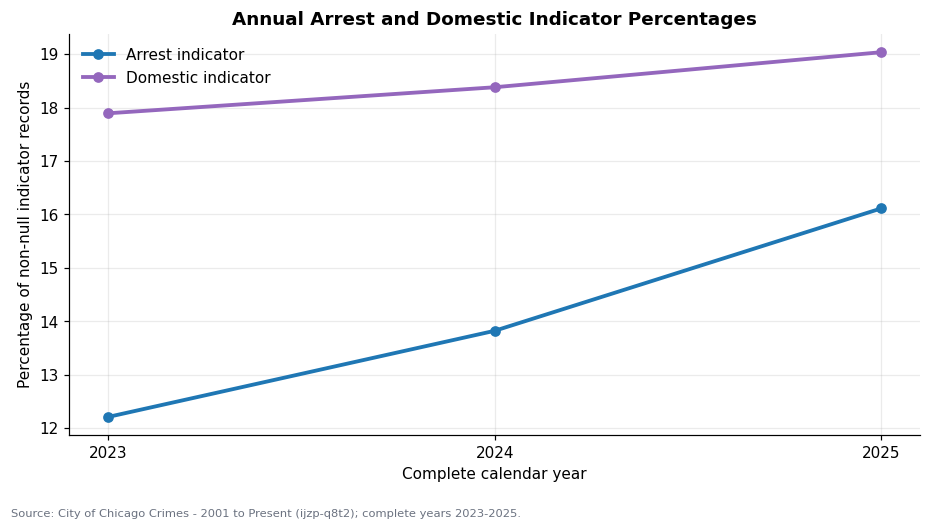

Saved images/python/python_arrest_domestic_trends.png


In [11]:
indicator_rows = []
for crime_year, group in records.groupby("crime_year"):
    arrest_denominator = int(group["arrest"].notna().sum())
    domestic_denominator = int(group["domestic"].notna().sum())
    arrest_count = int(group["arrest"].eq(True).sum())
    domestic_count = int(group["domestic"].eq(True).sum())
    indicator_rows.append({
        "crime_year": int(crime_year),
        "arrest_count": arrest_count,
        "arrest_denominator": arrest_denominator,
        "arrest_percentage": 100.0 * arrest_count / arrest_denominator if arrest_denominator else np.nan,
        "domestic_count": domestic_count,
        "domestic_denominator": domestic_denominator,
        "domestic_percentage": 100.0 * domestic_count / domestic_denominator if domestic_denominator else np.nan,
    })
indicators = pd.DataFrame(indicator_rows).sort_values("crime_year")
display(indicators.round(4))

fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.plot(indicators["crime_year"], indicators["arrest_percentage"], marker="o", linewidth=2.5,
        color=BLUE, label="Arrest indicator")
ax.plot(indicators["crime_year"], indicators["domestic_percentage"], marker="o", linewidth=2.5,
        color=PURPLE, label="Domestic indicator")
ax.set_title("Annual Arrest and Domestic Indicator Percentages")
ax.set_xlabel("Complete calendar year")
ax.set_ylabel("Percentage of non-null indicator records")
ax.set_xticks(indicators["crime_year"])
ax.legend(frameon=False)
save_figure(fig, "python_arrest_domestic_trends.png")

**Interpretation:** The arrest indicator increased while the domestic
indicator also represented a larger share of the smaller 2025 record
total. Neither series establishes a case outcome or cause.

## 8. Community-area comparisons

,community_area_count
areas_decreased,71
areas_increased,6
areas_unchanged,0


,community_area,community_area_name,previous_count,current_count,absolute_change,percentage_change,percentage_rank_eligible
11,12,FOREST GLEN,545,409,-136,-24.9541,True
24,25,AUSTIN,12958,11806,-1152,-8.8903,True


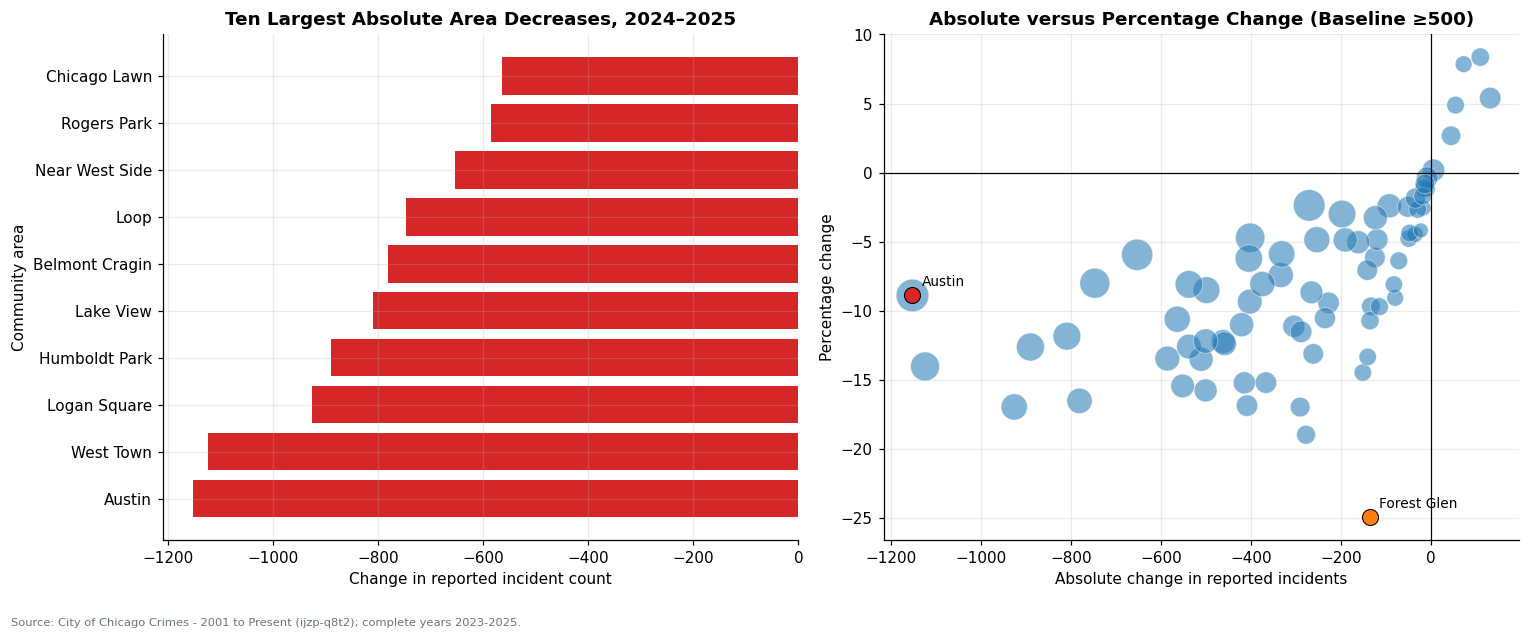

Saved images/python/python_community_area_yoy.png


In [12]:
community_lookup = pd.read_sql_query(
    text("SELECT * FROM public.vw_community_area_lookup ORDER BY community_area"), engine
)
area_counts = (
    records.loc[records["community_area_eligible_flag"]]
    .groupby(["crime_year", "community_area"], as_index=False)
    .size()
    .rename(columns={"size": "reported_incident_count"})
)
area_2024_2025 = (
    area_counts.loc[area_counts["crime_year"].isin([2024, 2025])]
    .pivot(index="community_area", columns="crime_year", values="reported_incident_count")
    .reindex(community_lookup["community_area"])
    .fillna(0)
    .rename(columns={2024: "previous_count", 2025: "current_count"})
    .reset_index()
    .merge(community_lookup, on="community_area", validate="one_to_one")
)
area_2024_2025["absolute_change"] = (
    area_2024_2025["current_count"] - area_2024_2025["previous_count"]
)
area_2024_2025["percentage_change"] = np.where(
    area_2024_2025["previous_count"].eq(0),
    np.nan,
    100.0 * area_2024_2025["absolute_change"] / area_2024_2025["previous_count"],
)
area_2024_2025["percentage_rank_eligible"] = area_2024_2025["previous_count"].ge(500)

direction_summary = pd.Series({
    "areas_decreased": int(area_2024_2025["absolute_change"].lt(0).sum()),
    "areas_increased": int(area_2024_2025["absolute_change"].gt(0).sum()),
    "areas_unchanged": int(area_2024_2025["absolute_change"].eq(0).sum()),
})
display(direction_summary.to_frame("community_area_count"))

largest_decreases = area_2024_2025.nsmallest(10, "absolute_change").sort_values("absolute_change")
forest_and_austin = area_2024_2025.loc[
    area_2024_2025["community_area"].isin([12, 25]),
    ["community_area", "community_area_name", "previous_count", "current_count",
     "absolute_change", "percentage_change", "percentage_rank_eligible"],
]
display(forest_and_austin.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))
axes[0].barh(
    largest_decreases["community_area_name"].str.title(),
    largest_decreases["absolute_change"],
    color=RED,
)
axes[0].set_title("Ten Largest Absolute Area Decreases, 2024–2025")
axes[0].set_xlabel("Change in reported incident count")
axes[0].set_ylabel("Community area")

eligible = area_2024_2025.loc[area_2024_2025["percentage_rank_eligible"]]
axes[1].scatter(
    eligible["absolute_change"], eligible["percentage_change"],
    s=np.sqrt(eligible["previous_count"]) * 4,
    alpha=0.55, color=BLUE, edgecolor="white", linewidth=0.5,
)
for area_number, color in [(12, ORANGE), (25, RED)]:
    point = eligible.loc[eligible["community_area"].eq(area_number)].iloc[0]
    axes[1].scatter(point["absolute_change"], point["percentage_change"],
                    s=110, color=color, edgecolor="black", linewidth=0.7, zorder=3)
    axes[1].annotate(point["community_area_name"].title(),
                     (point["absolute_change"], point["percentage_change"]),
                     xytext=(6, 6), textcoords="offset points", fontsize=9)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Absolute versus Percentage Change (Baseline ≥500)")
axes[1].set_xlabel("Absolute change in reported incidents")
axes[1].set_ylabel("Percentage change")
save_figure(fig, "python_community_area_yoy.png")

**Interpretation:** Forest Glen's proportional decline is large relative
to its baseline, while Austin's absolute decline represents many more
records. Community-area counts do not measure population-normalized risk.

## 9. Reproducible EDA summary

In [13]:
summary = pd.Series({
    "records_analyzed": len(records),
    "complete_years": records["crime_year"].nunique(),
    "2024_to_2025_absolute_change": int(yearly.loc[yearly["crime_year"].eq(2025), "absolute_change"].iloc[0]),
    "2024_to_2025_percentage_change": float(yearly.loc[yearly["crime_year"].eq(2025), "percentage_change"].iloc[0]),
    "2025_months_below_2024": months_lower_2025,
    "2025_areas_decreased": int(direction_summary["areas_decreased"]),
    "figures_saved": len(list(FIGURE_DIR.glob("python_*.png"))),
})
display(summary.to_frame("value"))

expected_figures = {
    "python_yearly_trend.png",
    "python_monthly_rolling_trend.png",
    "python_seasonal_by_year.png",
    "python_weekday_hourly_patterns.png",
    "python_category_yearly_trends.png",
    "python_category_monthly_profile.png",
    "python_arrest_domestic_trends.png",
    "python_community_area_yoy.png",
}
observed_figures = {path.name for path in FIGURE_DIR.glob("python_*.png")}
missing_figures = expected_figures - observed_figures
if missing_figures:
    raise AssertionError(f"Missing expected figures: {sorted(missing_figures)}")
print("PASS: all eight expected figures were generated.")

,value
records_analyzed,"761,563.0000"
complete_years,3.0000
2024_to_2025_absolute_change,"-21,547.0000"
2024_to_2025_percentage_change,-8.2990
2025_months_below_2024,12.0000
2025_areas_decreased,71.0000
figures_saved,8.0000


PASS: all eight expected figures were generated.


## Limitations

- The source measures reported incidents and can be revised after extraction.
- Murder rows represent victims rather than incidents according to the source.
- Community-area counts are not adjusted for population or exposure.
- Missing coordinates do not remove records from these non-map analyses.
- Source timestamps may be estimated, limiting precise hourly interpretation.
- Category, temporal, and indicator relationships are descriptive and non-causal.

In [14]:
engine.dispose()
print("Database engine disposed.")

Database engine disposed.
